<a href="https://colab.research.google.com/github/aryan2107-cloud/100-Day-ML-Challenge-/blob/main/Day31_Model_Selection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)

import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

In [ ]:
#Install boosting libraries
!pip install xgboost lightgbm -q
import xgboost as xgb
import lightgbm as lgb

In [ ]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"
columns = ['age', 'workclass', 'fnlwgt', 'education', 'education_num', 'marital_status',
           'occupation', 'relationship', 'race', 'sex', 'capital_gain', 'capital_loss',
           'hours_per_week', 'native_country', 'income']

df = pd.read_csv(url , names=columns, sep=',\s*', engine='python', na_values='?')

print(f"Dataset: {df.shape[0]:,} samples, {df.shape[1]} features")
print(f"\nTarget distributions: \n{df['income'].value_counts()}")

Dataset: 32,561 samples, 15 features

Target distributions: 
income
<=50K    24720
>50K      7841
Name: count, dtype: int64


In [ ]:
df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [ ]:
# Handle missing values
print(f"Missing values: {df.isnull().sum().sum()}")
df = df.dropna()
print(f"After dropping: {len(df):,} samples")

Missing values: 4262
After dropping: 30,162 samples


In [ ]:
# Separate features and target
x = df.drop('income', axis=1)
y = (df['income'] == '>50K').astype(int)  # Binary: 1 = >50K, 0 = <=50K

print(f"Features: {x.shape[1]}")
print(f"Target balance: {y.mean():.1%} positive class")

Features: 14
Target balance: 24.9% positive class


In [ ]:
numeric_cols = x.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = x.select_dtypes(include=['object']).columns.tolist()

print(f"Numeric Columns ({len(numeric_cols)}): {numeric_cols}")
print(f"Categorical Columns ({len(categorical_cols)}): {categorical_cols}")

Numeric Columns (6): ['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week']
Categorical Columns (8): ['workclass', 'education', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'native_country']


In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)

x_preprocessed = preprocessor.fit_transform(x).toarray()
x_preprocessed.shape

(30162, 104)

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x_preprocessed, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set: {x_train.shape[0]:,} samples")
print(f"Testing set: {x_test.shape[0]:,} samples")

Training set: 24,129 samples
Testing set: 6,033 samples


Define the Models

In [ ]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=10, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=15,
                                             random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, max_depth=5,
                                                     random_state=42),
    'XGBoost': xgb.XGBClassifier(n_estimators=100, max_depth=5,
                                  random_state=42, n_jobs=-1, verbosity=0),
    'LightGBM': lgb.LGBMClassifier(n_estimators=100, max_depth=5,
                                    random_state=42, n_jobs=-1, verbose=-1),
    'SVM (RBF)': SVC(kernel='linear', probability=True, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
    'Naive Bayes': GaussianNB()
}

print(f"Models: {len(models)}")
for name in models:
  print(f"  {name}")

Models: 9
  Logistic Regression
  Decision Tree
  Random Forest
  Gradient Boosting
  XGBoost
  LightGBM
  SVM (RBF)
  KNN
  Naive Bayes


In [ ]:
# Train and evaluate all models
results = []

print("Training all models...")
print("=" * 70)

for name, model in models.items():
    print(f"\n  {name}...", end=" ")

    # Time training
    start_time = time.time()
    model.fit(x_train, y_train)
    train_time = time.time() - start_time

    # Predictions
    start_time = time.time()
    y_pred = model.predict(x_test)
    predict_time = time.time() - start_time

    # Probabilities for ROC-AUC
    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(x_test)[:, 1]
        roc_auc = roc_auc_score(y_test, y_prob)
    else:
        roc_auc = np.nan

    # Metrics
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc,
        'Train Time (s)': train_time,
        'Predict Time (s)': predict_time
    })

    print(f"Done! (Accuracy: {results[-1]['Accuracy']:.4f})")

Training all models...

  Logistic Regression... Done! (Accuracy: 0.8470)

  Decision Tree... Done! (Accuracy: 0.8530)

  Random Forest... Done! (Accuracy: 0.8563)

  Gradient Boosting... Done! (Accuracy: 0.8628)

  XGBoost... Done! (Accuracy: 0.8671)

  LightGBM... Done! (Accuracy: 0.8646)

  SVM (RBF)... Done! (Accuracy: 0.8463)

  KNN... Done! (Accuracy: 0.8268)

  Naive Bayes... Done! (Accuracy: 0.5825)


In [ ]:
# Creating a results dataframe
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('F1', ascending=False).reset_index(drop=True)

print(results_df[['Model', 'Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']].round(4).to_string())

                 Model  Accuracy  Precision  Recall      F1  ROC-AUC
0              XGBoost    0.8671     0.7756  0.6558  0.7107   0.9249
1             LightGBM    0.8646     0.7778  0.6385  0.7013   0.9226
2    Gradient Boosting    0.8628     0.7713  0.6378  0.6983   0.9222
3        Random Forest    0.8563     0.7868  0.5799  0.6677   0.9144
4        Decision Tree    0.8530     0.7681  0.5866  0.6652   0.8959
5  Logistic Regression    0.8470     0.7348  0.6032  0.6625   0.9022
6            SVM (RBF)    0.8463     0.7472  0.5786  0.6522   0.8999
7                  KNN    0.8268     0.6664  0.6092  0.6365   0.8606
8          Naive Bayes    0.5825     0.3677  0.9407  0.5287   0.8025


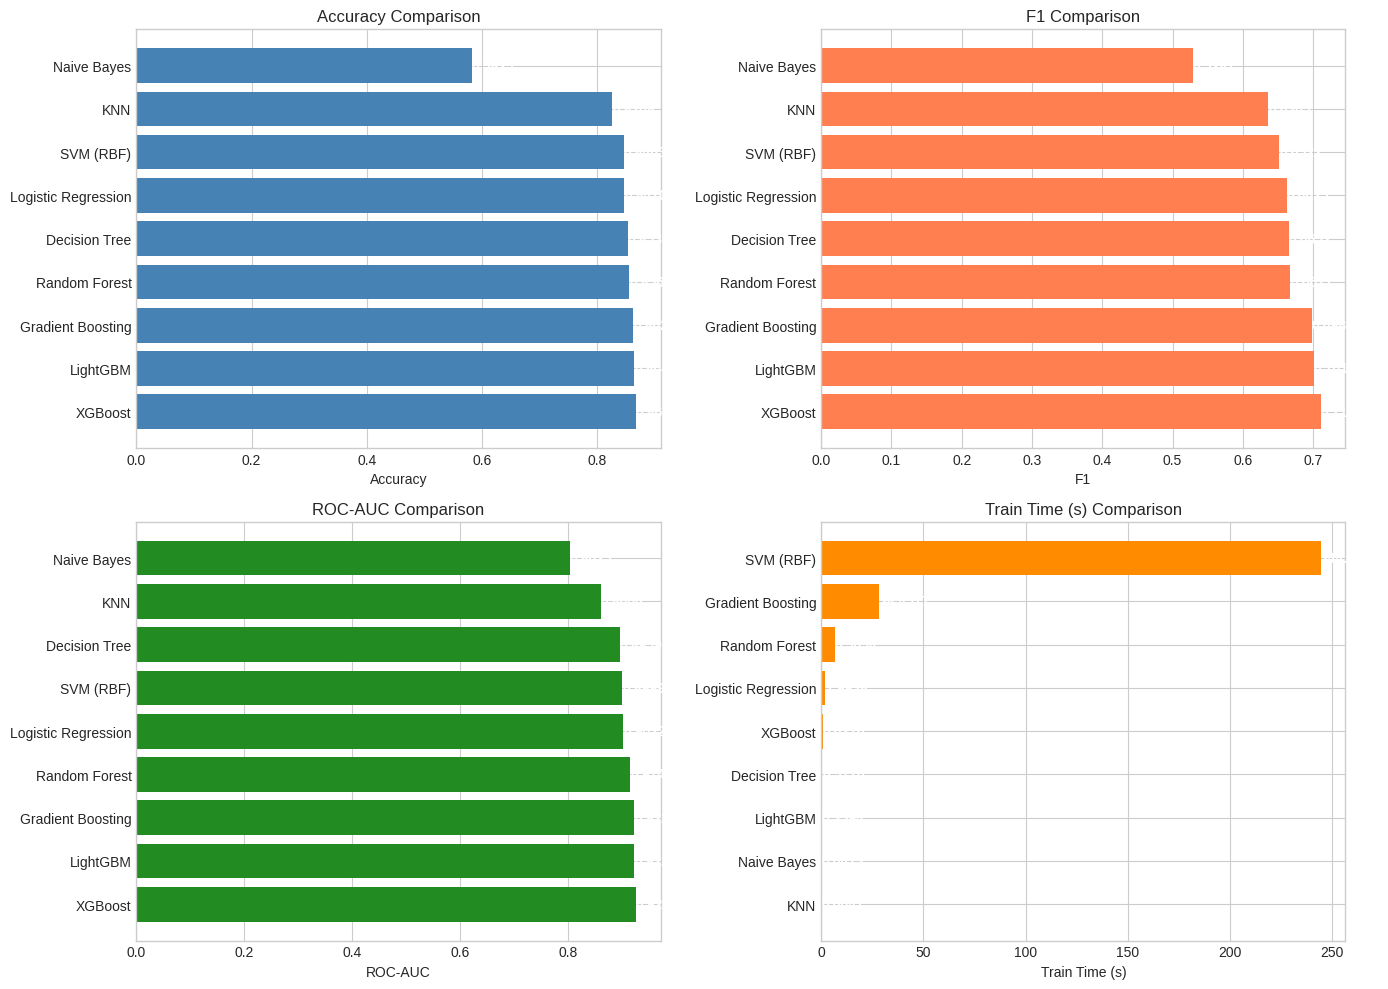

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

metrics=['Accuracy', 'F1', 'ROC-AUC', 'Train Time (s)']
colors = ['steelblue', 'coral', 'forestgreen', 'darkorange']

for ax, metric in zip(axes.flatten(), metrics):
  sorted_df = results_df.sort_values(metric, ascending=(metric == 'Train Time (s)'))
  bars = ax.barh(sorted_df['Model'], sorted_df[metric], color=colors[metrics.index(metric)])
  ax.set_xlabel(metric)
  ax.set_title(f"{metric} Comparison")

  for bar, val in zip(bars, sorted_df[metric]):
    if not np.isnan(val):
      ax.text(val, bar.get_y() + bar.get_height()/2, f"{val:.4f}", va='center', color='white', fontweight='bold')

plt.tight_layout()
plt.show()

Cross validation

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = []

for name, model in models.items():
  print(f"   {name}. . . ", end=" ")

  model_cv = type(model)(**model.get_params())

  scores = cross_val_score(model_cv, x_preprocessed,  y, cv=cv, scoring='f1', n_jobs=-1)

  cv_results.append({
      'Model': name,
      'CV Mean': scores.mean(),
      'CV Std': scores.std(),
      'CV Scores': scores
  })

  print(f"Done! (Mean: {cv_results[-1]['CV Mean']:.4f})")

cv_df = pd.DataFrame(cv_results).sort_values('CV Mean', ascending=False)
print("\nDone!")

   Logistic Regression. . .  Done! (Mean: 0.6663)
   Decision Tree. . .  Done! (Mean: 0.6658)
   Random Forest. . .  Done! (Mean: 0.6717)
   Gradient Boosting. . .  Done! (Mean: 0.7133)
   XGBoost. . .  Done! (Mean: 0.7212)
   LightGBM. . .  Done! (Mean: 0.7094)
   SVM (RBF). . .  Done! (Mean: 0.6553)
   KNN. . .  Done! (Mean: 0.6403)
   Naive Bayes. . .  Done! (Mean: 0.5173)

Done!


In [ ]:
# CV Results visualization
fig, ax = plt.subplots(figsize=(12, 6))

cv_df_sorted = cv_df.sort_values('CV Mean F1', ascending=True)
y_pos = range(len(cv_df_sorted))

ax.barh(y_pos, cv_df_sorted['CV Mean F1'], xerr=cv_df_sorted['CV Std F1'],
        color='steelblue', edgecolor='black', capsize=5)
ax.set_yticks(y_pos)
ax.set_yticklabels(cv_df_sorted['Model'])
ax.set_xlabel('F1 Score')
ax.set_title('Cross-Validation Results (F1 Score ± Std)')

plt.tight_layout()
plt.show()

SyntaxError: incomplete input (3644406784.py, line 6)

In [ ]:
# Box plot of CV scores
cv_scores_all = []
for r in cv_results:
    for score in r['CV Scores']:
        cv_scores_all.append({'Model': r['Model'], 'F1': score})

cv_scores_df = pd.DataFrame(cv_scores_all)

# Order by median
order = cv_df.sort_values('CV Mean F1', ascending=False)['Model'].tolist()

plt.figure(figsize=(12, 6))
sns.boxplot(data=cv_scores_df, x='Model', y='F1', order=order, palette='viridis')
plt.xticks(rotation=45, ha='right')
plt.xlabel('')
plt.ylabel('F1 Score')
plt.title('Cross-Validation F1 Score Distribution')
plt.tight_layout()
plt.show()

In [ ]:
# Scatter: Speed vs Performance
fig, ax = plt.subplots(figsize=(10, 7))

colors = plt.cm.viridis(np.linspace(0, 1, len(results_df)))

for i, row in results_df.iterrows():
    ax.scatter(row['Train Time (s)'], row['F1'], s=200, c=[colors[i-1]],
               edgecolor='black', linewidth=2)
    ax.annotate(row['Model'], (row['Train Time (s)'], row['F1']),
                xytext=(5, 5), textcoords='offset points', fontsize=9)

ax.set_xlabel('Training Time (seconds)')
ax.set_ylabel('F1 Score')
ax.set_title('Speed vs Performance Tradeoff')
ax.set_xscale('log')

# Add quadrant labels
ax.axhline(y=results_df['F1'].median(), color='red', linestyle='--', alpha=0.5)
ax.axvline(x=results_df['Train Time (s)'].median(), color='red', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print("Top-right: Fast AND accurate (ideal)")
print("Top-left: Accurate but slow")
print("Bottom-right: Fast but less accurate")


In [ ]:

# Top 4 models confusion matrices
top_models = results_df.head(4)['Model'].tolist()

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for ax, name in zip(axes, top_models):
    model = models[name]
    y_pred = model.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['<=50K', '>50K'], yticklabels=['<=50K', '>50K'])
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(f'{name}')

plt.suptitle('Confusion Matrices (Top 4 Models)', fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(10, 8))

for name, model in models.items():
    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, linewidth=2, label=f'{name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - All Models')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [ ]:
winner = final_df.iloc[0]
print(f"\n Overall : {winner['Model']}")
print(f"   F1: {winner['F1']:.4f}, CV F1: {winner['CV Mean F1']:.4f}")

fastest = final_df.loc[final_df['Train Time (s)'].idxmin()]
print(f"\n Fastest: {results_df.loc[results_df['Train Time (s)'].idxmin(), 'Model']}")
print(f"   Train time: {results_df['Train Time (s)'].min():.4f}s")

best_auc = final_df.loc[final_df['ROC-AUC'].idxmax()]
print(f"\n Best ROC-AUC: {best_auc['Model']}")
print(f"   ROC-AUC: {best_auc['ROC-AUC']:.4f}")

In [ ]:
print("📋 MODEL SELECTION GUIDE")
print("=" * 60)
print("""
🎯 BEST OVERALL PERFORMANCE:
   → Gradient Boosting (XGBoost, LightGBM)
   → Random Forest

⚡ FASTEST TRAINING:
   → Naive Bayes
   → Logistic Regression
   → Decision Tree

🔍 MOST INTERPRETABLE:
   → Logistic Regression (coefficients)
   → Decision Tree (rules)

📊 BEST FOR PROBABILITY ESTIMATES:
   → Logistic Regression
   → Random Forest
   → Gradient Boosting

🆕 LIMITED DATA:
   → Naive Bayes
   → Logistic Regression

📈 HIGH-DIMENSIONAL DATA:
   → Logistic Regression (with regularization)
   → Random Forest
   → SVM

🏃 PRODUCTION / REAL-TIME:
   → LightGBM (fastest inference)
   → Logistic Regression (simple)
""")